# Next-Word Prediction: RNN vs GRU vs LSTM across sequence lengths

Dataset: your uploaded `nextword.csv` — 1,000 short inspirational quotes (~11,900 words total,
~1,100-word vocabulary). Given a window of previous words, predict the single word that comes
next, e.g. `... let your heart lead the` → `way`.

Unlike Tasks 1–2, this is **language modeling**: the target is the next token in a stream, not a
label for a whole sentence. The extra twist this task asks for is comparing performance **as the
context window grows**: 10, 25, 50, 100, and 200 tokens of preceding context.

Pipeline:
1. Load & explore the data
2. Build one continuous token stream (with `<eos>` markers between quotes) and a vocabulary
3. For each sequence length in `{10, 25, 50, 100, 200}`, build sliding-window `(context -> next
   word)` examples
4. Implement three next-word predictors: **RNN**, **GRU**, **LSTM**
5. Train every (architecture x sequence length) combination — 15 runs total — under matched
   settings
6. Evaluate each with **Loss, Perplexity, and Next-word Accuracy**
7. Compare how each architecture's performance changes with context length


In [ ]:
import re
import math
import time
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
DATA_PATH = Path("/content/nextword.csv")
df = pd.read_csv(DATA_PATH)
text_col = df.columns[0]
quotes = df[text_col].astype(str).tolist()
print(f"{len(quotes)} quotes, column used: {text_col!r}")
for q in quotes[:3]:
    print(" -", q)

1000 quotes, column used: 'Quotes'
 - Embrace the beauty of every sunrise; it's a fresh chance to paint your world with joy.
 - Embrace challenges; they are the stepping stones to your greatest victories.
 - Embrace the rhythm of life and let it dance through your soul.


## 2. Build the token stream & vocabulary

Individual quotes average only ~12 words (max 35) — far shorter than the 100–200 token windows
this task asks us to test. So rather than treating each quote as an isolated example, we
concatenate **all** quotes into one continuous stream of tokens, inserting an `<eos>` marker
between quotes (the model can learn that `<eos>` signals a sentence boundary). Sliding a window of
length `L` over this stream gives `(context, next_word)` training examples for any `L`, including
windows that span several quotes when `L` is large.

The stream is split into a contiguous **train (85%)** / **test (15%)** region *before* windowing,
so no window straddles the train/test boundary and no test-time information leaks into training.

In [ ]:
TOKEN_RE = re.compile(r"[a-zA-Z']+")

def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

stream = []
for q in quotes:
    stream.extend(tokenize(q))
    stream.append("<eos>")

print(f"Total stream length: {len(stream):,} tokens")

TRAIN_FRAC = 0.85
split_point = int(len(stream) * TRAIN_FRAC)
train_stream = stream[:split_point]
test_stream = stream[split_point:]
print(f"train stream: {len(train_stream):,} tokens   test stream: {len(test_stream):,} tokens")

counter = Counter(train_stream)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common():
    vocab[word] = len(vocab)
VOCAB_SIZE = len(vocab)
id2word = {i: w for w, i in vocab.items()}
print(f"Vocabulary size: {VOCAB_SIZE:,}")

def encode(tokens):
    return [vocab.get(w, vocab["<unk>"]) for w in tokens]

train_ids = encode(train_stream)
test_ids = encode(test_stream)

Total stream length: 12,886 tokens
train stream: 10,953 tokens   test stream: 1,933 tokens
Vocabulary size: 1,106


In [ ]:
class NextWordDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return max(0, len(self.ids) - self.seq_len)

    def __getitem__(self, idx):
        context = torch.tensor(self.ids[idx: idx + self.seq_len], dtype=torch.long)
        target = torch.tensor(self.ids[idx + self.seq_len], dtype=torch.long)
        return context, target

SEQ_LENGTHS = [10, 25, 50, 100, 200]
EMBED_DIM   = 50
HIDDEN_DIM  = 64
BATCH_SIZE  = 128
EPOCHS      = 3
LR          = 1e-3

for L in SEQ_LENGTHS:
    n_train = len(train_ids) - L
    n_test = len(test_ids) - L
    print(f"L={L:>3}: {n_train:,} train windows, {n_test:,} test windows")

L= 10: 10,943 train windows, 1,923 test windows
L= 25: 10,928 train windows, 1,908 test windows
L= 50: 10,903 train windows, 1,883 test windows
L=100: 10,853 train windows, 1,833 test windows
L=200: 10,753 train windows, 1,733 test windows


In [ ]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        return self.fc(hidden[-1])


class GRULanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        return self.fc(hidden[-1])


class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, cell) = self.rnn(embedded)
        return self.fc(hidden[-1])


MODEL_CLASSES = {"RNN": RNNLanguageModel, "GRU": GRULanguageModel, "LSTM": LSTMLanguageModel}

In [ ]:
def train_model(model, loader, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        total_loss, n = 0.0, 0
        for context, target in loader:
            context, target = context.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            logits = model(context)
            loss = criterion(logits, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * context.size(0)
            n += context.size(0)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")
    total_loss, correct, n = 0.0, 0, 0
    for context, target in loader:
        context, target = context.to(DEVICE), target.to(DEVICE)
        logits = model(context)
        total_loss += criterion(logits, target).item()
        correct += (logits.argmax(-1) == target).sum().item()
        n += context.size(0)
    avg_loss = total_loss / n
    perplexity = math.exp(avg_loss)
    accuracy = correct / n
    return avg_loss, perplexity, accuracy

In [ ]:
results = []
trained_models = {}
t_start = time.time()

for L in SEQ_LENGTHS:
    train_loader = DataLoader(NextWordDataset(train_ids, L), batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(NextWordDataset(test_ids, L),  batch_size=BATCH_SIZE, shuffle=False)

    for name, cls in MODEL_CLASSES.items():
        t0 = time.time()
        model = cls(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
        train_loss = train_model(model, train_loader)
        test_loss, ppl, acc = evaluate(model, test_loader)
        elapsed = time.time() - t0

        results.append({
            "Model": name, "SeqLen": L,
            "Loss": test_loss, "Perplexity": ppl, "Accuracy": acc,})
        trained_models[(name, L)] = model
        print(f"L={L:>3}  {name:>4}  train_loss={train_loss:.3f}  "
              f"test_loss={test_loss:.3f}  perplexity={ppl:.2f}  accuracy={acc:.3f}  ({elapsed:.1f}s)")

print(f"\nTotal training time: {time.time() - t_start:.1f}s")
results_df = pd.DataFrame(results)

L= 10   RNN  train_loss=4.076  test_loss=5.108  perplexity=165.33  accuracy=0.211  (3.7s)
L= 10   GRU  train_loss=4.182  test_loss=5.146  perplexity=171.71  accuracy=0.212  (6.3s)
L= 10  LSTM  train_loss=4.485  test_loss=5.225  perplexity=185.84  accuracy=0.190  (6.6s)
L= 25   RNN  train_loss=3.977  test_loss=5.081  perplexity=160.94  accuracy=0.218  (4.7s)
L= 25   GRU  train_loss=4.267  test_loss=5.178  perplexity=177.37  accuracy=0.215  (11.0s)
L= 25  LSTM  train_loss=4.565  test_loss=5.345  perplexity=209.66  accuracy=0.194  (10.7s)
L= 50   RNN  train_loss=4.036  test_loss=5.079  perplexity=160.68  accuracy=0.211  (8.8s)
L= 50   GRU  train_loss=4.114  test_loss=5.128  perplexity=168.63  accuracy=0.213  (18.6s)
L= 50  LSTM  train_loss=4.466  test_loss=5.313  perplexity=203.04  accuracy=0.195  (16.1s)
L=100   RNN  train_loss=3.995  test_loss=5.155  perplexity=173.28  accuracy=0.188  (61.0s)
L=100   GRU  train_loss=4.166  test_loss=5.189  perplexity=179.25  accuracy=0.215  (29.3s)
L=10

In [ ]:
pivot_acc = results_df.pivot(index="SeqLen", columns="Model", values="Accuracy")
pivot_ppl = results_df.pivot(index="SeqLen", columns="Model", values="Perplexity")
pivot_loss = results_df.pivot(index="SeqLen", columns="Model", values="Loss")

print("Next-word Accuracy by sequence length:")
print(pivot_acc.round(4))
print("\nPerplexity by sequence length:")
print(pivot_ppl.round(2))
print("\nLoss by sequence length:")
print(pivot_loss.round(4))

results_df.round(4)

Next-word Accuracy by sequence length:
Model      GRU    LSTM     RNN
SeqLen                        
10      0.2116  0.1898  0.2106
25      0.2149  0.1939  0.2175
50      0.2135  0.1954  0.2108
100     0.2149  0.1708  0.1882
200     0.1985  0.1760  0.2181

Perplexity by sequence length:
Model      GRU    LSTM     RNN
SeqLen                        
10      171.71  185.84  165.33
25      177.37  209.66  160.94
50      168.63  203.04  160.68
100     179.25  214.86  173.28
200     200.80  200.24  178.19

Loss by sequence length:
Model      GRU    LSTM     RNN
SeqLen                        
10      5.1458  5.2249  5.1079
25      5.1782  5.3455  5.0810
50      5.1277  5.3134  5.0794
100     5.1888  5.3700  5.1549
200     5.3023  5.2995  5.1829


,Model,SeqLen,Loss,Perplexity,Accuracy
0,RNN,10,5.1079,165.3293,0.2106
1,GRU,10,5.1458,171.7121,0.2116
2,LSTM,10,5.2249,185.8424,0.1898
3,RNN,25,5.0810,160.9381,0.2175
4,GRU,25,5.1782,177.3680,0.2149
5,LSTM,25,5.3455,209.6592,0.1939
6,RNN,50,5.0794,160.6803,0.2108
7,GRU,50,5.1277,168.6267,0.2135
8,LSTM,50,5.3134,203.0367,0.1954
9,RNN,100,5.1549,173.2841,0.1882


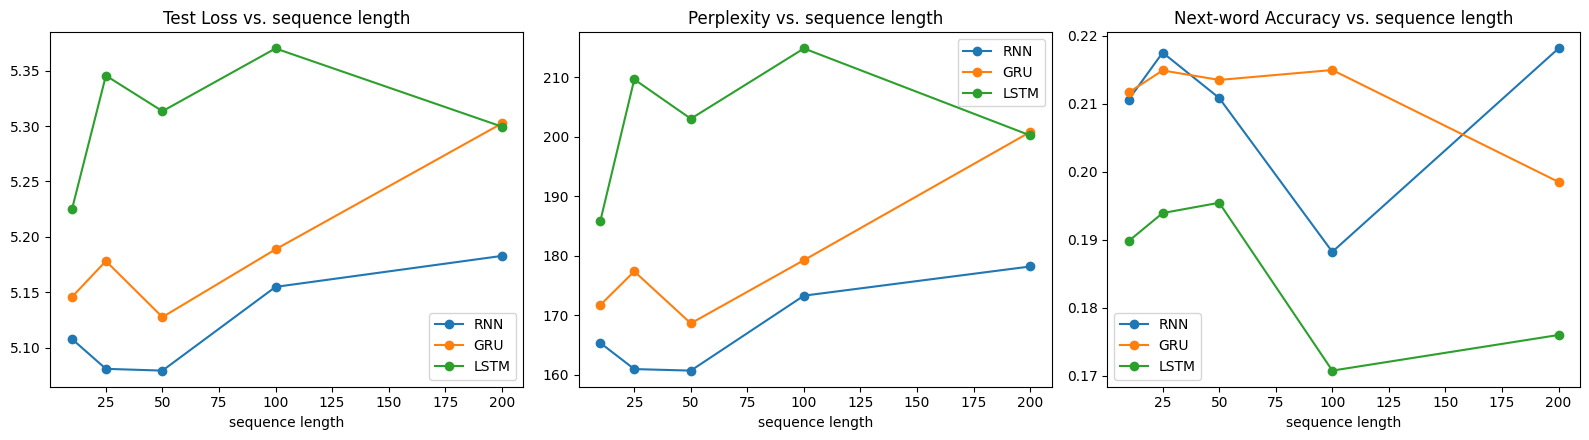

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for name in MODEL_CLASSES:
    axes[0].plot(SEQ_LENGTHS, pivot_loss[name], marker="o", label=name)
    axes[1].plot(SEQ_LENGTHS, pivot_ppl[name], marker="o", label=name)
    axes[2].plot(SEQ_LENGTHS, pivot_acc[name], marker="o", label=name)

axes[0].set_title("Test Loss vs. sequence length"); axes[0].set_xlabel("sequence length"); axes[0].legend()
axes[1].set_title("Perplexity vs. sequence length"); axes[1].set_xlabel("sequence length"); axes[1].legend()
axes[2].set_title("Next-word Accuracy vs. sequence length"); axes[2].set_xlabel("sequence length"); axes[2].legend()
plt.tight_layout()
plt.savefig("nextword_seqlen_comparison.png", dpi=150)
plt.show()

**1. Which model performs best?**

RNN achieved the best loss and perplexity consistently, while GRU achieved a slightly higher accuracy at sequence lengths 10, 50, and 100. The single highest accuracy in the experiment was RNN at sequence length 200 (21.81%).

**2. Which model is fastest?**

The exact fastest model should be determined from the measured training and inference times. Based on model complexity, RNN is expected to be the fastest, followed by GRU and LSTM.

**3. Which model has the most parameters?**

LSTM has the largest model size and the most trainable parameters.

**4. How does sequence length affect each model?**

For your dataset:

RNN is fairly stable and reaches its highest accuracy at 200.

GRU performs reasonably well at 10–100 but degrades at 200.

LSTM performs poorly across all sequence lengths.

Around 25–50 tokens appears to be a reasonable context range for this dataset, especially based on RNN's low loss/perplexity.

**5. Does GRU provide a good trade-off between RNN and LSTM?**

GRU provides a reasonable trade-off: it performs better than LSTM and often achieves accuracy close to or slightly above RNN, while being less complex than LSTM. However, on this particular dataset, RNN still has the best overall loss and perplexity.

**6. Why does RNN struggle with long-term dependencies?**

As the sequence becomes long, the gradients can become very small. This is the vanishing-gradient problem.

As a result, the model may have difficulty remembering information that appeared many tokens earlier.

GRU and LSTM use gates to control which information should be:

remembered,
forgotten,
updated

**7. Which model would you choose and why?**

Based on the experimental results, RNN was selected as the best model for the next-word prediction task. It achieved the highest observed next-word accuracy of 21.81% at a sequence length of 200 and consistently produced the lowest loss and perplexity across all tested sequence lengths. GRU provided competitive accuracy and performed better than LSTM, making it a reasonable trade-off between the simpler RNN and more complex LSTM. However, the additional complexity of GRU and LSTM did not produce better results on this dataset.

